In [1]:
import json
from collections import defaultdict
from pathlib import Path

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import wandb
import xarray as xr
from context_flux_no.metrics import relative_L2_error, relative_L_infty_error
from context_flux_no.training.io import load_model
from einops import rearrange
from jaxtyping import Array, Float
from matplotlib.animation import ArtistAnimation
from tqdm import tqdm


datadir = Path("../../data")
checkpoint_dir = Path("../../checkpoints")

jax.config.update("jax_default_device", jax.devices("gpu")[0])

In [2]:
@eqx.filter_jit
def compute_metrics(model, u, args, context_length=20):
    context, u_data = u[:context_length], u[context_length:]

    u_pred = model.rollout(context, args, num_steps=len(u_data))[0]

    return {
        "l2_onestep": relative_L2_error(u_pred[0], u_data[0]),
        "l_inf_onestep": relative_L_infty_error(u_pred[0], u_data[0]),
        "l2_rollout": relative_L2_error(u_pred, u_data),
        "l_inf_rollout": relative_L_infty_error(u_pred, u_data),
    }


In [6]:
model_paths = {
    "DPOT": [
        "seed=0/26-04-10-14:49:05",
        "seed=10/26-04-16-18:37:37",
        "seed=20/26-04-17-07:57:49",
    ],
    "HyperFluxFNOLocal": [
        "seed=0/26-04-16-00:31:47",
        "seed=10/26-04-17-07:57:49",
        "seed=20/26-04-17-10:50:08",
    ],
    "DISCO": [
        "seed=0/26-04-10-21:26:22",
        "seed=10/26-04-16-18:37:50",
        "seed=20/26-04-16-18:37:50",
    ],
}

## Query wandb API and obtain loss curves

In [169]:
api = wandb.Api()
run_dpot = api.run("jhko725/hyperfluxfno/cgwa58nd")
run_hyperfluxfno = api.run("jhko725/hyperfluxfno/nni87so3")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/jhko725/.netrc.


<IPython.core.display.Javascript object>

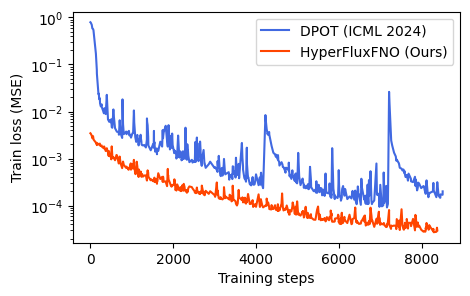

In [184]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(
    *run_dpot.history(keys=["train_loss"]).to_numpy().T,
    label="DPOT (ICML 2024)",
    color="royalblue",
)
ax.plot(
    *run_hyperfluxfno.history(keys=["train_loss"]).to_numpy().T,
    label="HyperFluxFNO (Ours)",
    color="orangered",
)
ax.set_yscale("log", base=10)
ax.set_ylabel("Train loss (MSE)")
ax.set_xlabel("Training steps")
ax.legend()
fig

## Evaluation on the in-distribution test set

In [3]:
dataset_test = (
    xr.open_dataset(
        datadir
        / "datasets/cubic_no_source/data/test/cubic_no_source_large_test_seed=10.hdf5",
        engine="h5netcdf",
        chunks={},
    )
    .isel(t=slice(None, None, 10))
    .isel({"t": slice(0, 99)})
)
dt = float(dataset_test["t"][1] - dataset_test["t"][0])
dx = float(dataset_test["x"][1] - dataset_test["x"][0])

values = rearrange(dataset_test["values"].values, "pde ic ... -> (pde ic) ...")
segments = np.lib.stride_tricks.sliding_window_view(values, 40, axis=1)
segments = rearrange(segments, "batch t0 c x t -> (batch t0) t c x")
segments.shape

(600000, 40, 1, 100)

In [ ]:
dt = float(dataset_test["t"][1] - dataset_test["t"][0])
dx = float(dataset_test["x"][1] - dataset_test["x"][0])
results_dict = defaultdict(list)
for model_type, paths in model_paths.items():
    for p in tqdm(paths):
        model = load_model(checkpoint_dir / model_type / "OneStepLoss" / p)
        model = eqx.nn.inference_mode(model, True)
        results = jax.lax.map(
            eqx.filter_jit(lambda u: compute_metrics(model, u, (dt, dx))),
            segments,
            batch_size=6000,
        )
        print(jax.tree.map(lambda x: x.shape, results))
        results_dict[model_type].append(jax.tree.map(jnp.mean, results))


  0%|          | 0/3 [00:00<?, ?it/s]

E0425 00:51:08.562697 4100831 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0425 00:51:14.594975 4100857 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0425 00:51:15.150975 4100846 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


{'l2_onestep': (600000,), 'l2_rollout': (600000,), 'l_inf_onestep': (600000,), 'l_inf_rollout': (600000,)}


 67%|██████▋   | 2/3 [05:43<02:49, 169.09s/it]

{'l2_onestep': (600000,), 'l2_rollout': (600000,), 'l_inf_onestep': (600000,), 'l_inf_rollout': (600000,)}


...

{'l2_onestep': (600000,), 'l2_rollout': (600000,), 'l_inf_onestep': (600000,), 'l_inf_rollout': (600000,)}


 67%|██████▋   | 2/3 [57:36<28:36, 1716.45s/it]

{'l2_onestep': (600000,), 'l2_rollout': (600000,), 'l_inf_onestep': (600000,), 'l_inf_rollout': (600000,)}


100%|██████████| 3/3 [1:32:34<00:00, 1851.39s/it]

{'l2_onestep': (600000,), 'l2_rollout': (600000,), 'l_inf_onestep': (600000,), 'l_inf_rollout': (600000,)}


In [7]:
results_dict

defaultdict(list,
            {'DPOT': [{'l2_onestep': Array(0.00741473, dtype=float32),
               'l2_rollout': Array(0.13300796, dtype=float32),
               'l_inf_onestep': Array(0.02428744, dtype=float32),
               'l_inf_rollout': Array(0.67084366, dtype=float32)},
              {'l2_onestep': Array(0.00749846, dtype=float32),
               'l2_rollout': Array(0.1403646, dtype=float32),
               'l_inf_onestep': Array(0.02454978, dtype=float32),
               'l_inf_rollout': Array(0.69166344, dtype=float32)},
              {'l2_onestep': Array(0.007278, dtype=float32),
               'l2_rollout': Array(0.13489507, dtype=float32),
               'l_inf_onestep': Array(0.02363556, dtype=float32),
               'l_inf_rollout': Array(0.6715672, dtype=float32)}],
             'HyperFluxFNOLocal': [{'l2_onestep': Array(0.00423209, dtype=float32),
               'l2_rollout': Array(0.05501814, dtype=float32),
               'l_inf_onestep': Array(0.01618657, dty

In [ ]:
with open("../../data/analysis/cubic_1d_indistribution.json", "w") as f:
    json.dump(jax.tree.map(lambda x: float(x), results_dict), f)

In [9]:
for model_name, res in results_dict.items():
    res_ = jax.tree.transpose(jax.tree.structure(["*"] * 3), None, res)
    print(
        model_name,
        jax.tree.map(
            lambda list_: {
                "mean": jnp.mean(jnp.asarray(list_)),
                "std": jnp.std(jnp.asarray(list_)),
            },
            res_,
            is_leaf=lambda x: isinstance(x, list),
        ),
    )

DPOT {'l2_onestep': {'mean': Array(0.00739706, dtype=float32), 'std': Array(9.0866575e-05, dtype=float32)}, 'l2_rollout': {'mean': Array(0.1360892, dtype=float32), 'std': Array(0.00311978, dtype=float32)}, 'l_inf_onestep': {'mean': Array(0.02415759, dtype=float32), 'std': Array(0.00038435, dtype=float32)}, 'l_inf_rollout': {'mean': Array(0.67802477, dtype=float32), 'std': Array(0.00964852, dtype=float32)}}
HyperFluxFNOLocal {'l2_onestep': {'mean': Array(0.00410069, dtype=float32), 'std': Array(0.00011422, dtype=float32)}, 'l2_rollout': {'mean': Array(0.05207125, dtype=float32), 'std': Array(0.0021486, dtype=float32)}, 'l_inf_onestep': {'mean': Array(0.0154488, dtype=float32), 'std': Array(0.00061139, dtype=float32)}, 'l_inf_rollout': {'mean': Array(0.36791477, dtype=float32), 'std': Array(0.01562881, dtype=float32)}}
DISCO {'l2_onestep': {'mean': Array(0.01064843, dtype=float32), 'std': Array(0.00198619, dtype=float32)}, 'l2_rollout': {'mean': Array(0.08218265, dtype=float32), 'std': A

In [10]:
(jax.tree.transpose(jax.tree.structure(["*"] * 3), None, results_dict["DPOT"]),)

({'l2_onestep': [Array(0.00741498, dtype=float32),
   Array(0.00749871, dtype=float32),
   Array(0.00727814, dtype=float32)],
  'l_inf_onestep': [Array(0.02428802, dtype=float32),
   Array(0.02455009, dtype=float32),
   Array(0.023636, dtype=float32)]},)

## Calculate results for the OOD dataset

In [18]:
dataset_test = (
    xr.open_dataset(
        datadir / "datasets/cubic_no_source/data/test/sine_1d_test_step_seed=12.hdf5",
        engine="h5netcdf",
        chunks={},
    )
    .isel(t=slice(None, None, 10))
    .isel({"t": slice(0, 99)})
)
dt = float(dataset_test["t"][1] - dataset_test["t"][0])
dx = float(dataset_test["x"][1] - dataset_test["x"][0])

values = rearrange(dataset_test["values"].values, "pde ic ... -> (pde ic) ...")
segments = np.lib.stride_tricks.sliding_window_view(values, 40, axis=1)
segments = rearrange(segments, "batch t0 c x t -> (batch t0) t c x")
segments.shape

(600000, 40, 1, 100)

In [19]:
dt = float(dataset_test["t"][1] - dataset_test["t"][0])
dx = float(dataset_test["x"][1] - dataset_test["x"][0])
results_dict = defaultdict(list)
for model_type, paths in model_paths.items():
    for p in tqdm(paths):
        model = load_model(checkpoint_dir / model_type / "OneStepLoss" / p)
        model = eqx.nn.inference_mode(model, True)
        results = jax.lax.map(
            eqx.filter_jit(lambda u: compute_metrics(model, u, (dt, dx))),
            segments,
            batch_size=6000,
        )
        print(jax.tree.map(lambda x: x.shape, results))
        results_dict[model_type].append(jax.tree.map(jnp.mean, results))

with open("../../data/analysis/cubic_1d_ood_sine_step.json", "w") as f:
    json.dump(jax.tree.map(lambda x: float(x), results_dict), f)

 33%|███▎      | 1/3 [03:21<06:43, 201.51s/it]

{'l2_onestep': (600000,), 'l2_rollout': (600000,), 'l_inf_onestep': (600000,), 'l_inf_rollout': (600000,)}


 67%|██████▋   | 2/3 [06:44<03:22, 202.64s/it]

{'l2_onestep': (600000,), 'l2_rollout': (600000,), 'l_inf_onestep': (600000,), 'l_inf_rollout': (600000,)}


100%|██████████| 3/3 [10:08<00:00, 202.85s/it]


...

{'l2_onestep': (600000,), 'l2_rollout': (600000,), 'l_inf_onestep': (600000,), 'l_inf_rollout': (600000,)}


 67%|██████▋   | 2/3 [52:50<26:34, 1594.32s/it]

{'l2_onestep': (600000,), 'l2_rollout': (600000,), 'l_inf_onestep': (600000,), 'l_inf_rollout': (600000,)}


100%|██████████| 3/3 [1:18:46<00:00, 1575.57s/it]

{'l2_onestep': (600000,), 'l2_rollout': (600000,), 'l_inf_onestep': (600000,), 'l_inf_rollout': (600000,)}


In [20]:
with open("../../data/analysis/cubic_1d_ood_sine_step.json", "r") as f:
    results = json.load(f)
results

{'DISCO': [{'l2_onestep': 0.012223337776958942,
   'l2_rollout': 0.10119239240884781,
   'l_inf_onestep': 0.0494585819542408,
   'l_inf_rollout': 0.55856853723526},
  {'l2_onestep': 0.008803834207355976,
   'l2_rollout': 0.08699070662260056,
   'l_inf_onestep': 0.03567821532487869,
   'l_inf_rollout': 0.5079464316368103},
  {'l2_onestep': 0.007499767001718283,
   'l2_rollout': 0.08216618001461029,
   'l_inf_onestep': 0.03116152249276638,
   'l_inf_rollout': 0.5497355461120605}],
 'DPOT': [{'l2_onestep': 0.007757244631648064,
   'l2_rollout': 0.17166508734226227,
   'l_inf_onestep': 0.028324661776423454,
   'l_inf_rollout': 0.8852067589759827},
  {'l2_onestep': 0.008103858679533005,
   'l2_rollout': 0.17475645244121552,
   'l_inf_onestep': 0.027827847748994827,
   'l_inf_rollout': 0.9122693538665771},
  {'l2_onestep': 0.00763496570289135,
   'l2_rollout': 0.18280069530010223,
   'l_inf_onestep': 0.026168115437030792,
   'l_inf_rollout': 0.9901280403137207}],
 'HyperFluxFNOLocal': [{'l2_

In [21]:
for model_name, res in results.items():
    res_ = jax.tree.transpose(jax.tree.structure(["*"] * 3), None, res)
    print(
        model_name,
        jax.tree.map(
            lambda list_: {
                "mean": jnp.mean(jnp.asarray(list_)),
                "std": jnp.std(jnp.asarray(list_)),
            },
            res_,
            is_leaf=lambda x: isinstance(x, list),
        ),
    )

DISCO {'l2_onestep': {'mean': Array(0.00950898, dtype=float32), 'std': Array(0.00199181, dtype=float32)}, 'l2_rollout': {'mean': Array(0.09011643, dtype=float32), 'std': Array(0.00807576, dtype=float32)}, 'l_inf_onestep': {'mean': Array(0.03876611, dtype=float32), 'std': Array(0.00778233, dtype=float32)}, 'l_inf_rollout': {'mean': Array(0.5387502, dtype=float32), 'std': Array(0.02207802, dtype=float32)}}
DPOT {'l2_onestep': {'mean': Array(0.00783202, dtype=float32), 'std': Array(0.00019859, dtype=float32)}, 'l2_rollout': {'mean': Array(0.17640743, dtype=float32), 'std': Array(0.00469359, dtype=float32)}, 'l_inf_onestep': {'mean': Array(0.02744021, dtype=float32), 'std': Array(0.00092209, dtype=float32)}, 'l_inf_rollout': {'mean': Array(0.92920136, dtype=float32), 'std': Array(0.04447576, dtype=float32)}}
HyperFluxFNOLocal {'l2_onestep': {'mean': Array(0.00484765, dtype=float32), 'std': Array(0.00028508, dtype=float32)}, 'l2_rollout': {'mean': Array(0.06060863, dtype=float32), 'std': Ar

## Compare model performance for different training methods

In [3]:
dataset_train = xr.open_dataset(
    datadir / "cubic_no_source_large_train.hdf5", engine="h5netcdf", chunks={}
)
dataset_train_extrap = dataset_train.isel({"t": slice(61, None)})

batch_extrap = dataset_train_extrap["values"].isel({"ic": 10}).compute().to_numpy()

dt = float(dataset_train_extrap["t"][1] - dataset_train_extrap["t"][0])
dx = float(dataset_train_extrap["x"][1] - dataset_train_extrap["x"][0])


### DPOT

100%|██████████| 3/3 [00:15<00:00,  5.26s/it]


Text(0.5, 0.98, 'DPOT')

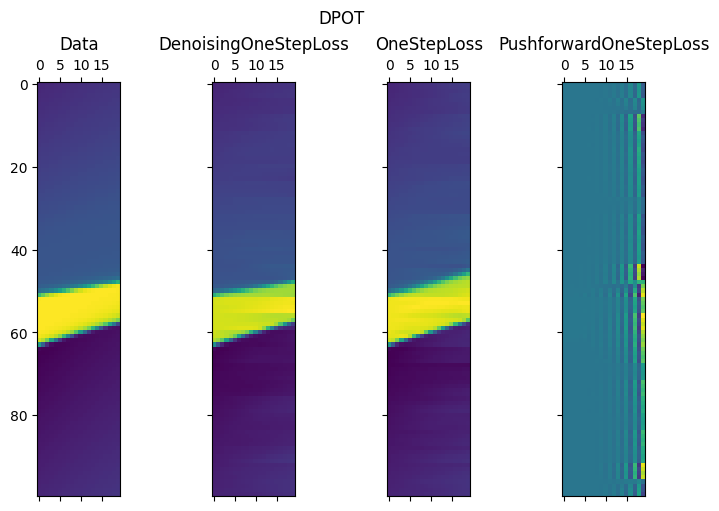

In [4]:
u_pred_dict = dict()

for method, ckpt_name in tqdm(CHECKPOINT_DICT["DPOT"].items()):
    model = load_model(checkpoint_dir / "DPOT" / method / ckpt_name)
    model = eqx.nn.inference_mode(model, True)

    u_pred_dict[method] = eqx.filter_vmap(
        lambda u: model.rollout(u, args=None, num_steps=20)
    )(batch_extrap[:, :20])[0]

sample_idx = 0
fig, axes = plt.subplots(
    1, 4, figsize=(7, 5), constrained_layout=True, sharex=True, sharey=True
)
axes[0].matshow(batch_extrap[sample_idx, 20:, 0].T)
axes[0].set_title("Data")
for i, (method, u_pred) in enumerate(u_pred_dict.items()):
    axes[i + 1].matshow(u_pred[sample_idx, :, 0].T)
    axes[i + 1].set_title(method)
fig.suptitle("DPOT")


  0%|          | 0/3 [00:00<?, ?it/s]E0319 17:06:43.667190  393440 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0319 17:06:45.153165  393440 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
100%|██████████| 3/3 [00:27<00:00,  9.04s/it]


Text(0.5, 0.98, 'HyperFluxFNO')

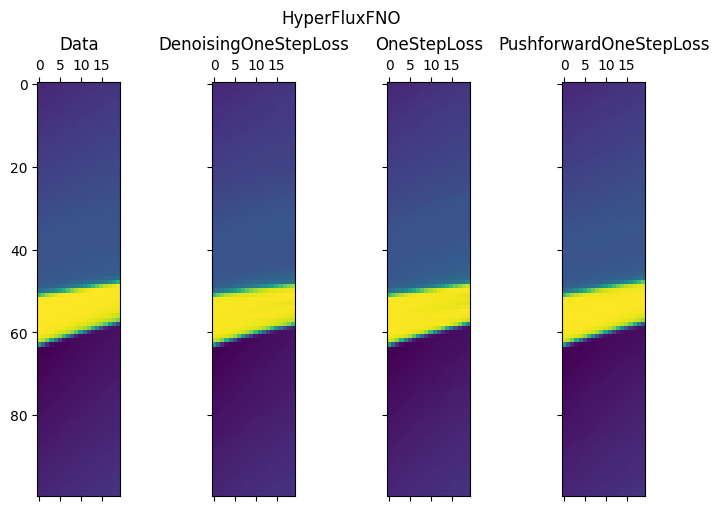

In [5]:
u_pred_dict = dict()

dt = float(dataset_train_extrap["t"][1] - dataset_train_extrap["t"][0])
dx = float(dataset_train_extrap["x"][1] - dataset_train_extrap["x"][0])

model_type = "HyperFluxFNO"
for method, ckpt_name in tqdm(CHECKPOINT_DICT[model_type].items()):
    model = load_model(checkpoint_dir / model_type / method / ckpt_name)
    model = eqx.nn.inference_mode(model, True)

    u_pred_dict[method] = eqx.filter_vmap(
        lambda u: model.rollout(u, args=(dt, dx), num_steps=20)
    )(batch_extrap[:, :20])[0]

sample_idx = 0
fig, axes = plt.subplots(
    1, 4, figsize=(7, 5), constrained_layout=True, sharex=True, sharey=True
)
axes[0].matshow(batch_extrap[sample_idx, 20:, 0].T)
axes[0].set_title("Data")
for i, (method, u_pred) in enumerate(u_pred_dict.items()):
    axes[i + 1].matshow(u_pred[sample_idx, :, 0].T)
    axes[i + 1].set_title(method)
fig.suptitle(model_type)


Text(0.5, 1.0, 'HyperFluxFNO')

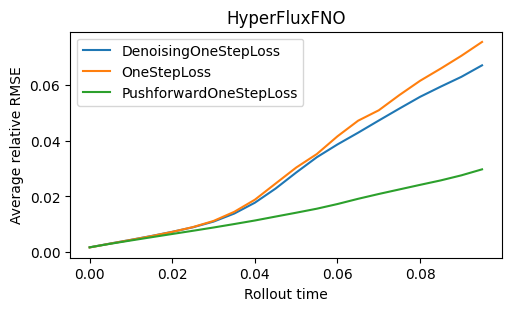

In [19]:
def relative_rmse(
    u_pred: Float[Array, "channels ..."], u_data: Float[Array, "channels ..."]
):
    return jnp.sqrt(jnp.mean((u_pred - u_data) ** 2)) / jnp.sqrt(jnp.mean(u_data**2))


sample_idx = 0
fig, ax = plt.subplots(1, 1, figsize=(5, 3), constrained_layout=True)
for i, (method, u_pred) in enumerate(u_pred_dict.items()):
    rel_rmse = jnp.mean(
        jax.vmap(jax.vmap(relative_rmse))(batch_extrap[:, 20:], u_pred),
        axis=0,
    )
    ax.plot(jnp.arange(len(rel_rmse)) * dt, rel_rmse, label=method)
ax.set_ylabel("Average relative RMSE")
ax.set_xlabel("Rollout time")
ax.legend()
ax.set_title(model_type)

100%|██████████| 3/3 [02:09<00:00, 43.16s/it]


Text(0.5, 0.98, 'HyperFluxFNOLocal')

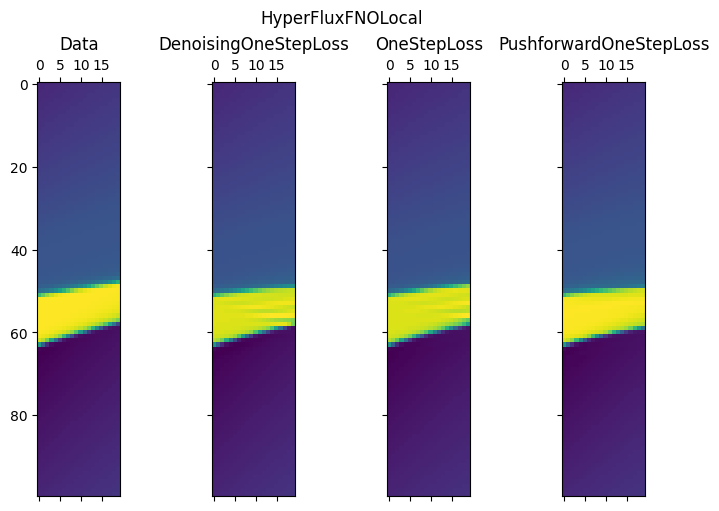

In [20]:
u_pred_dict = dict()

dt = float(dataset_train_extrap["t"][1] - dataset_train_extrap["t"][0])
dx = float(dataset_train_extrap["x"][1] - dataset_train_extrap["x"][0])

model_type = "HyperFluxFNOLocal"
for method, ckpt_name in tqdm(CHECKPOINT_DICT[model_type].items()):
    model = load_model(checkpoint_dir / model_type / method / ckpt_name)
    model = eqx.nn.inference_mode(model, True)

    u_pred_dict[method] = eqx.filter_vmap(
        lambda u: model.rollout(u, args=(dt, dx), num_steps=20)
    )(batch_extrap[:, :20])[0]

sample_idx = 0
fig, axes = plt.subplots(
    1, 4, figsize=(7, 5), constrained_layout=True, sharex=True, sharey=True
)
axes[0].matshow(batch_extrap[sample_idx, 20:, 0].T)
axes[0].set_title("Data")
for i, (method, u_pred) in enumerate(u_pred_dict.items()):
    axes[i + 1].matshow(u_pred[sample_idx, :, 0].T)
    axes[i + 1].set_title(method)
fig.suptitle(model_type)


Text(0.5, 1.0, 'HyperFluxFNOLocal')

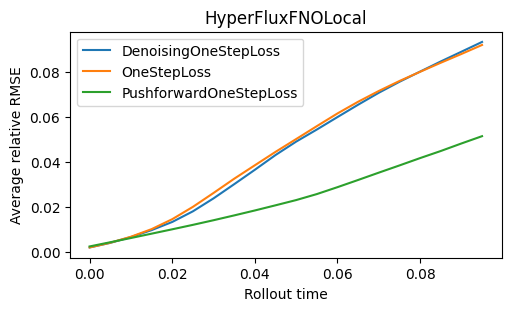

In [ ]:
sample_idx = 0
fig, ax = plt.subplots(1, 1, figsize=(5, 3), constrained_layout=True)
for i, (method, u_pred) in enumerate(u_pred_dict.items()):
    rel_rmse = jnp.mean(
        jax.vmap(jax.vmap(relative_rmse))(batch_extrap[:, 20:], u_pred),
        axis=0,
    )
    ax.plot(jnp.arange(len(rel_rmse)) * dt, rel_rmse, label=method)
ax.set_ylabel("Average relative RMSE")
ax.set_xlabel("Rollout time")
ax.legend()
ax.set_title(model_type)

## Compare best results

In [4]:
u_pred_dict = dict()

# model_method_list = [
#     ("DPOT", "DenoisingOneStepLoss"),
#     ("HyperFluxFNO", "PushforwardOneStepLoss"),
#     ("HyperFluxFNOLocal", "PushforwardOneStepLoss"),
# ]
model_paths = {
    "DPOT": "OneStepLoss/seed=0/26-04-10-14:49:05",
    "HyperFluxFNOLocal": "OneStepLoss/seed=0/26-04-16-00:31:47",
    "DISCO": "OneStepLoss/seed=0/26-04-10-21:26:22",
}
for model_type, path in tqdm(model_paths.items()):
    model = load_model(checkpoint_dir / model_type / path)
    model = eqx.nn.inference_mode(model, True)

    u_pred_dict[model_type] = eqx.filter_vmap(
        lambda u: model.rollout(u, args=(dt, dx), num_steps=20)
    )(batch_extrap[:, :20])[0]

 33%|███▎      | 1/3 [00:13<00:27, 13.77s/it]/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/models/multiphysics/hyperfluxfno/encoders/utils.py:50: UserWarning: TRecViTEncoder supports variable in_timesteps. The given 
                    in_timesteps value will be ignored.
  warnings.warn(
/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/nn/structured_linear.py:40: UserWarning: out_features is not divisible by num_blocks. Output vector 
            will be truncated to the requested size.
  warnings.warn("""out_features is not divisible by num_blocks. Output vector
E0416 11:04:41.905982  814596 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0416 11:04:42.298533  814580 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
 67%|██████▋   | 2/3 [00

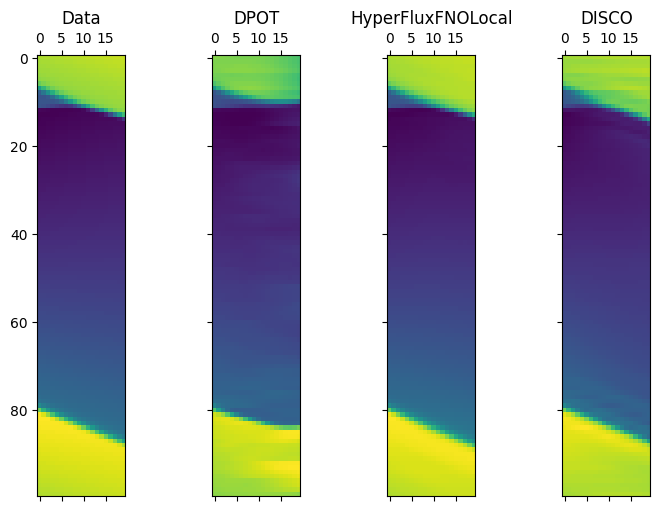

In [5]:
sample_idx = 100
fig, axes = plt.subplots(
    1, 4, figsize=(7, 5), constrained_layout=True, sharex=True, sharey=True
)
axes[0].matshow(batch_extrap[sample_idx, 20:, 0].T)
axes[0].set_title("Data")
for i, (model_type, u_pred) in enumerate(u_pred_dict.items()):
    axes[i + 1].matshow(u_pred[sample_idx, :, 0].T)
    axes[i + 1].set_title(model_type)


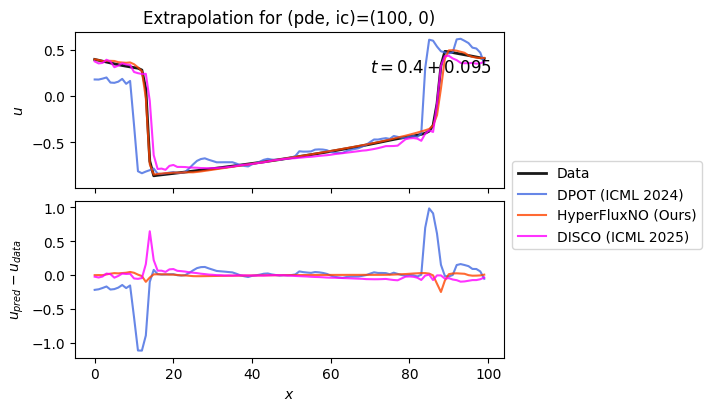

In [6]:
plt.rcParams["animation.html"] = "jshtml"
fig, axes = plt.subplots(2, 1, figsize=(7, 4), sharex=True, constrained_layout=True)

COLOR_DICT = {
    "DPOT": "royalblue",
    "HyperFluxFNOLocal": "orangered",
    "DISCO": "magenta",
}
LABEL_DICT = {
    "DPOT": "DPOT (ICML 2024)",
    "HyperFluxFNOLocal": "HyperFluxNO (Ours)",
    "DISCO": "DISCO (ICML 2025)",
}


def make_frame(timestep: int):
    if timestep == 0:
        plot_kwargs = {"animated": False}
        axes[-1].set_xlabel("$x$")
        axes[0].set_ylabel("$u$")
        axes[1].set_ylabel("$u_{pred}-u_{data}$")
    else:
        plot_kwargs = {"animated": True}

    plot1 = axes[0].plot(
        batch_extrap[sample_idx, 20 + timestep, 0].T,
        label="Data",
        linewidth=2.0,
        color="black",
        alpha=0.9,
        **plot_kwargs,
    )[0]
    plots = []
    for model_type, u_pred in u_pred_dict.items():
        p0 = axes[0].plot(
            u_pred[sample_idx, timestep, 0].T,
            label=LABEL_DICT[model_type],
            alpha=0.8,
            linewidth=1.5,
            color=COLOR_DICT[model_type],
            **plot_kwargs,
        )[0]
        p1 = axes[1].plot(
            u_pred[sample_idx, timestep, 0].T
            - batch_extrap[sample_idx, 20 + timestep, 0].T,
            label=LABEL_DICT[model_type],
            alpha=0.8,
            linewidth=1.5,
            color=COLOR_DICT[model_type],
            **plot_kwargs,
        )[0]
        plots.append(p0)
        plots.append(p1)

    text_y = (
        jnp.max(batch_extrap[sample_idx, :, 0]) * 0.8
        + jnp.min(batch_extrap[sample_idx, :, 0]) * 0.2
    )
    text0 = axes[0].text(70, text_y, f"$t=0.4+{dt * timestep:.3f}$", fontsize="large")
    if timestep == 0:
        fig.legend(*axes[0].get_legend_handles_labels(), loc="outside center right")
    axes[0].set_title(f"Extrapolation for (pde, ic)={(sample_idx, 0)}")
    return (plot1, *plots, text0)


frames = [make_frame(i) for i in range(20)]


ani = ArtistAnimation(fig, frames, interval=50, blit=True)
# ani.save(f"../../figures/cubic_extrapolation_{sample_idx}_0.gif")
ani

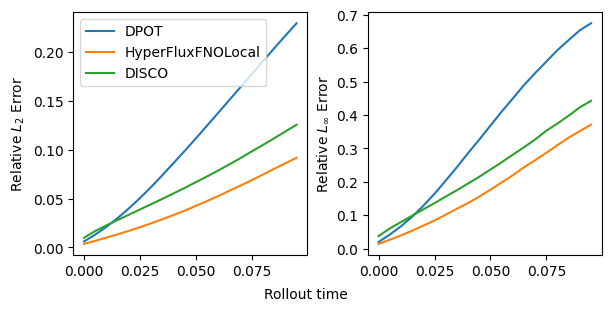

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3), constrained_layout=True)
for i, (model_type, u_pred) in enumerate(u_pred_dict.items()):
    rel_L2 = jnp.mean(
        jax.vmap(jax.vmap(relative_L2_error))(batch_extrap[:, 20:], u_pred),
        axis=0,
    )
    axes[0].plot(jnp.arange(len(rel_L2)) * dt, rel_L2, label=model_type)

    rel_L_infty = jnp.mean(
        jax.vmap(jax.vmap(relative_L_infty_error))(batch_extrap[:, 20:], u_pred),
        axis=0,
    )
    axes[1].plot(jnp.arange(len(rel_L_infty)) * dt, rel_L_infty, label=model_type)
axes[0].set_ylabel(r"Relative $L_2$ Error")
axes[1].set_ylabel(r"Relative $L_\infty$ Error")
fig.supxlabel("Rollout time", fontsize="medium")
axes[0].legend()


## Evaluation on the test set

In [ ]:
dataset_test = xr.open_dataset(
    datadir
    / "datasets/cubic_no_source/data/test/cubic_no_source_large_test_seed=10.hdf5",
    engine="h5netcdf",
    chunks={},
).isel(t=slice(None, None, 10))

# batch_test = dataset_test["values"].isel({"ic": 10}).compute().to_numpy()
# num_steps = 50

In [10]:
dataset_test

<xarray.Dataset> Size: 808MB
Dimensions:  (pde: 100, ic: 100, t: 101, dim: 1, x: 100, param: 3)
Coordinates:
  * t        (t) float64 808B 0.0 0.005 0.01 0.015 0.02 ... 0.485 0.49 0.495 0.5
  * dim      (dim) <U1 4B 'u'
  * x        (x) float64 800B 0.005 0.015 0.025 0.035 ... 0.975 0.985 0.995
  * param    (param) <U1 12B 'a' 'b' 'c'
Dimensions without coordinates: pde, ic
Data variables:
    values   (pde, ic, t, dim, x) float64 808MB dask.array<chunksize=(100, 100, 101, 1, 100), meta=np.ndarray>
    coeffs   (pde, param) float64 2kB dask.array<chunksize=(100, 3), meta=np.ndarray>

In [11]:
batch_test = dataset_test["values"].isel({"ic": 10}).compute().to_numpy()
batch_test.shape

(100, 101, 1, 100)

In [7]:
num_steps = 10
u_pred_dict = dict()

for method, ckpt_name in tqdm(CHECKPOINT_DICT["DPOT"].items()):
    model = load_model(checkpoint_dir / "DPOT" / method / ckpt_name)
    model = eqx.nn.inference_mode(model, True)

    u_pred_dict[method] = eqx.filter_vmap(
        lambda u: model.rollout(u, args=None, num_steps=num_steps)
    )(batch_test[:, :20])[0]

sample_idx = 0
fig, axes = plt.subplots(
    1, 4, figsize=(7, 5), constrained_layout=True, sharex=True, sharey=True
)
axes[0].matshow(batch_test[sample_idx, 20 : 20 + num_steps, 0].T)
axes[0].set_title("Data")
for i, (method, u_pred) in enumerate(u_pred_dict.items()):
    axes[i + 1].matshow(u_pred[sample_idx, :, 0].T)
    axes[i + 1].set_title(method)
fig.suptitle("DPOT")


NameError: name 'CHECKPOINT_DICT' is not defined

In [9]:
u_pred_dict = dict()

dt = float(dataset_test["t"][1] - dataset_test["t"][0])
dx = float(dataset_test["x"][1] - dataset_test["x"][0])

model_type = "HyperFluxFNO"
for method, ckpt_name in tqdm(CHECKPOINT_DICT[model_type].items()):
    model = load_model(checkpoint_dir / model_type / method / ckpt_name)
    model = eqx.nn.inference_mode(model, True)

    u_pred_dict[method] = eqx.filter_vmap(
        lambda u: model.rollout(u, args=(dt, dx), num_steps=num_steps)
    )(batch_test[:, :20])[0]

sample_idx = 0
fig, axes = plt.subplots(
    1, 4, figsize=(7, 5), constrained_layout=True, sharex=True, sharey=True
)
axes[0].matshow(batch_test[sample_idx, 20 : 20 + num_steps, 0].T)
axes[0].set_title("Data")
for i, (method, u_pred) in enumerate(u_pred_dict.items()):
    axes[i + 1].matshow(u_pred[sample_idx, :, 0].T)
    axes[i + 1].set_title(method)
fig.suptitle(model_type)


NameError: name 'CHECKPOINT_DICT' is not defined

Text(0.5, 1.0, 'HyperFluxFNO')

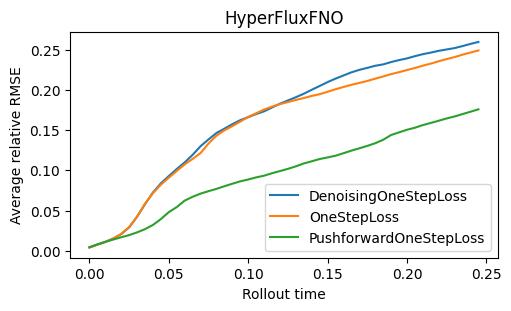

In [19]:
def relative_rmse(
    u_pred: Float[Array, "channels ..."], u_data: Float[Array, "channels ..."]
):
    return jnp.sqrt(jnp.mean((u_pred - u_data) ** 2)) / jnp.sqrt(jnp.mean(u_data**2))


sample_idx = 0
fig, ax = plt.subplots(1, 1, figsize=(5, 3), constrained_layout=True)
for i, (method, u_pred) in enumerate(u_pred_dict.items()):
    rel_rmse = jnp.mean(
        jax.vmap(jax.vmap(relative_rmse))(batch_test[:, 20 : 20 + num_steps], u_pred),
        axis=0,
    )
    ax.plot(jnp.arange(len(rel_rmse)) * dt, rel_rmse, label=method)
ax.set_ylabel("Average relative RMSE")
ax.set_xlabel("Rollout time")
ax.legend()
ax.set_title(model_type)

100%|██████████| 3/3 [00:12<00:00,  4.24s/it]


Text(0.5, 0.98, 'HyperFluxFNOLocal')

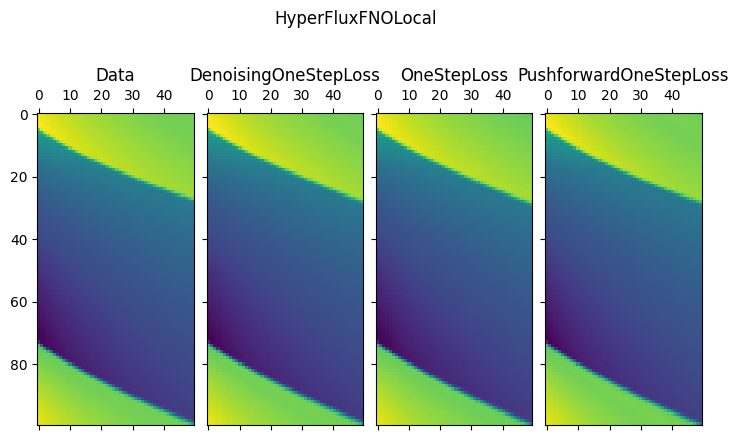

In [20]:
u_pred_dict = dict()

dt = float(dataset_test["t"][1] - dataset_test["t"][0])
dx = float(dataset_test["x"][1] - dataset_test["x"][0])

model_type = "HyperFluxFNOLocal"
for method, ckpt_name in tqdm(CHECKPOINT_DICT[model_type].items()):
    model = load_model(checkpoint_dir / model_type / method / ckpt_name)
    model = eqx.nn.inference_mode(model, True)

    u_pred_dict[method] = eqx.filter_vmap(
        lambda u: model.rollout(u, args=(dt, dx), num_steps=num_steps)
    )(batch_test[:, :20])[0]

sample_idx = 0
fig, axes = plt.subplots(
    1, 4, figsize=(7, 5), constrained_layout=True, sharex=True, sharey=True
)
axes[0].matshow(batch_test[sample_idx, 20 : 20 + num_steps, 0].T)
axes[0].set_title("Data")
for i, (method, u_pred) in enumerate(u_pred_dict.items()):
    axes[i + 1].matshow(u_pred[sample_idx, :, 0].T)
    axes[i + 1].set_title(method)
fig.suptitle(model_type)


Text(0.5, 1.0, 'HyperFluxFNOLocal')

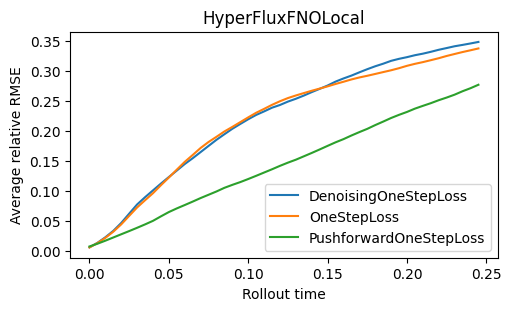

In [21]:
def relative_rmse(
    u_pred: Float[Array, "channels ..."], u_data: Float[Array, "channels ..."]
):
    return jnp.sqrt(jnp.mean((u_pred - u_data) ** 2)) / jnp.sqrt(jnp.mean(u_data**2))


sample_idx = 0
fig, ax = plt.subplots(1, 1, figsize=(5, 3), constrained_layout=True)
for i, (method, u_pred) in enumerate(u_pred_dict.items()):
    rel_rmse = jnp.mean(
        jax.vmap(jax.vmap(relative_rmse))(batch_test[:, 20 : 20 + num_steps], u_pred),
        axis=0,
    )
    ax.plot(jnp.arange(len(rel_rmse)) * dt, rel_rmse, label=method)
ax.set_ylabel("Average relative RMSE")
ax.set_xlabel("Rollout time")
ax.legend()
ax.set_title(model_type)

In [12]:
dt = float(dataset_test["t"][1] - dataset_test["t"][0])
dx = float(dataset_test["x"][1] - dataset_test["x"][0])

for model_type, path in tqdm(model_paths.items()):
    model = load_model(checkpoint_dir / model_type / path)
    model = eqx.nn.inference_mode(model, True)

    u_pred_dict[model_type] = eqx.filter_vmap(
        lambda u: model.rollout(u, args=(dt, dx), num_steps=20)
    )(batch_test[:, :20])[0]

 33%|███▎      | 1/3 [00:04<00:08,  4.41s/it]/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/models/multiphysics/hyperfluxfno/encoders/utils.py:50: UserWarning: TRecViTEncoder supports variable in_timesteps. The given 
                    in_timesteps value will be ignored.
  warnings.warn(
/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/nn/structured_linear.py:40: UserWarning: out_features is not divisible by num_blocks. Output vector 
            will be truncated to the requested size.
  warnings.warn("""out_features is not divisible by num_blocks. Output vector
E0416 11:08:37.086473  814637 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
 67%|██████▋   | 2/3 [00:12<00:06,  6.66s/it]/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1269: UserWarning: Sharding info not provid

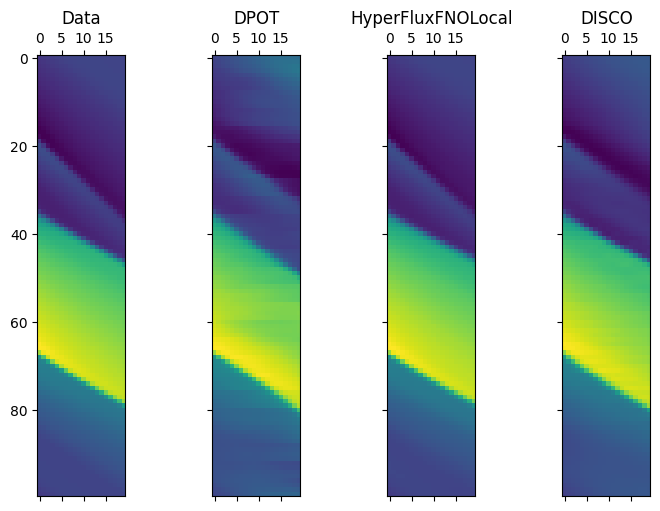

In [50]:
sample_idx = 20
fig, axes = plt.subplots(
    1, 4, figsize=(7, 5), constrained_layout=True, sharex=True, sharey=True
)
axes[0].matshow(batch_test[sample_idx, 20:40, 0].T)
axes[0].set_title("Data")
for i, (model_type, u_pred) in enumerate(u_pred_dict.items()):
    axes[i + 1].matshow(u_pred[sample_idx, :, 0].T)
    axes[i + 1].set_title(model_type)


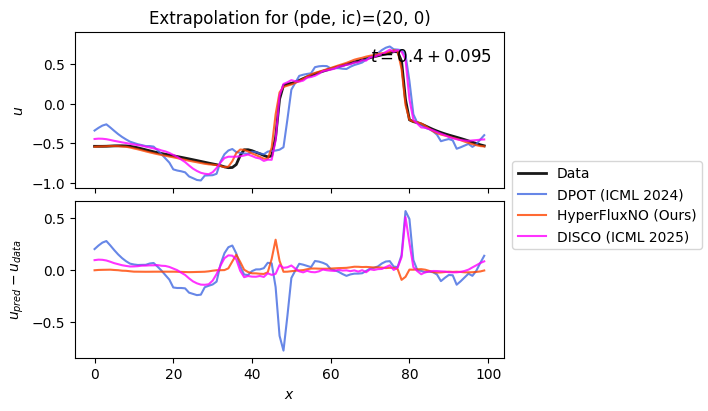

In [52]:
plt.rcParams["animation.html"] = "jshtml"
fig, axes = plt.subplots(2, 1, figsize=(7, 4), sharex=True, constrained_layout=True)

COLOR_DICT = {
    "DPOT": "royalblue",
    "HyperFluxFNOLocal": "orangered",
    "DISCO": "magenta",
}
LABEL_DICT = {
    "DPOT": "DPOT (ICML 2024)",
    "HyperFluxFNOLocal": "HyperFluxNO (Ours)",
    "DISCO": "DISCO (ICML 2025)",
}


def make_frame(timestep: int):
    if timestep == 0:
        plot_kwargs = {"animated": False}
        axes[-1].set_xlabel("$x$")
        axes[0].set_ylabel("$u$")
        axes[1].set_ylabel("$u_{pred}-u_{data}$")
    else:
        plot_kwargs = {"animated": True}

    plot1 = axes[0].plot(
        batch_test[sample_idx, 20 + timestep, 0].T,
        label="Data",
        linewidth=2.0,
        color="black",
        alpha=0.9,
        **plot_kwargs,
    )[0]
    plots = []
    for model_type, u_pred in u_pred_dict.items():
        p0 = axes[0].plot(
            u_pred[sample_idx, timestep, 0].T,
            label=LABEL_DICT[model_type],
            alpha=0.8,
            linewidth=1.5,
            color=COLOR_DICT[model_type],
            **plot_kwargs,
        )[0]
        p1 = axes[1].plot(
            u_pred[sample_idx, timestep, 0].T
            - batch_test[sample_idx, 20 + timestep, 0].T,
            label=LABEL_DICT[model_type],
            alpha=0.8,
            linewidth=1.5,
            color=COLOR_DICT[model_type],
            **plot_kwargs,
        )[0]
        plots.append(p0)
        plots.append(p1)

    text_y = (
        jnp.max(batch_test[sample_idx, :, 0]) * 0.8
        + jnp.min(batch_test[sample_idx, :, 0]) * 0.2
    )
    text0 = axes[0].text(70, text_y, f"$t=0.4+{dt * timestep:.3f}$", fontsize="large")
    if timestep == 0:
        fig.legend(*axes[0].get_legend_handles_labels(), loc="outside center right")
    axes[0].set_title(f"Extrapolation for (pde, ic)={(sample_idx, 0)}")
    return (plot1, *plots, text0)


frames = [make_frame(i) for i in range(20)]


ani = ArtistAnimation(fig, frames, interval=50, blit=True)
ani.save(f"../../figures/cubic_test_{sample_idx}_0.gif")
ani

In [17]:
model_paths = {
    "DPOT": "OneStepLoss/seed=0/26-04-10-14:49:05",
    "HyperFluxFNOLocal": "OneStepLoss/seed=0/26-04-16-00:31:47",
    "DISCO": "OneStepLoss/seed=0/26-04-10-21:26:22",
}

In [18]:
import numpy as np
from einops import rearrange


dataset_test = (
    xr.open_dataset(
        datadir
        / "datasets/cubic_no_source/data/test/cubic_no_source_large_test_seed=10.hdf5",
        engine="h5netcdf",
        chunks={},
    )
    .isel(t=slice(None, None, 10))
    .isel(t=slice(0, 80))
)

values = rearrange(dataset_test["values"].values, "pde ic ... -> (pde ic) ...")
segments = np.lib.stride_tricks.sliding_window_view(values, 21, axis=1)
segments = rearrange(segments, "batch t0 c x t -> (batch t0) t c x")
segments.shape

(600000, 21, 1, 100)

In [19]:
dt = float(dataset_test["t"][1] - dataset_test["t"][0])
dx = float(dataset_test["x"][1] - dataset_test["x"][0])
results = {}
for model_type, path in tqdm(model_paths.items()):
    model = load_model(checkpoint_dir / model_type / path)
    model = eqx.nn.inference_mode(model, True)

    @eqx.filter_jit
    def _compute_metrics(_u):
        _u_pred = model(_u[:-1], (dt, dx))[0]
        return {
            "L2": relative_L2_error(_u_pred, _u[-1]),
            "L_infty": relative_L_infty_error(_u_pred, _u[-1]),
        }

    results[model_type] = jax.tree.map(
        jnp.mean, jax.lax.map(_compute_metrics, segments, batch_size=2000)
    )

 33%|███▎      | 1/3 [00:11<00:23, 11.96s/it]/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/models/multiphysics/hyperfluxfno/encoders/utils.py:50: UserWarning: TRecViTEncoder supports variable in_timesteps. The given 
                    in_timesteps value will be ignored.
  warnings.warn(
/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/nn/structured_linear.py:40: UserWarning: out_features is not divisible by num_blocks. Output vector 
            will be truncated to the requested size.
  warnings.warn("""out_features is not divisible by num_blocks. Output vector
E0416 11:11:15.231097  814623 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0416 11:11:15.411928  814623 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0416 11:11:15.593898  8

In [21]:
results

{'DPOT': {'L2': Array(0.00741475, dtype=float32),
  'L_infty': Array(0.02428749, dtype=float32)},
 'HyperFluxFNOLocal': {'L2': Array(0.00423209, dtype=float32),
  'L_infty': Array(0.01618657, dtype=float32)},
 'DISCO': {'L2': Array(0.01339875, dtype=float32),
  'L_infty': Array(0.05237685, dtype=float32)}}

In [22]:
dataset_test = (
    xr.open_dataset(
        datadir
        / "datasets/cubic_no_source/data/test/cubic_no_source_large_test_seed=10.hdf5",
        engine="h5netcdf",
        chunks={},
    )
    .isel(t=slice(None, None, 10))
    .isel(t=slice(80, None))
)

values = rearrange(dataset_test["values"].values, "pde ic ... -> (pde ic) ...")
segments = np.lib.stride_tricks.sliding_window_view(values, 21, axis=1)
segments = rearrange(segments, "batch t0 c x t -> (batch t0) t c x")
segments.shape

(10000, 21, 1, 100)

In [23]:
dt = float(dataset_test["t"][1] - dataset_test["t"][0])
dx = float(dataset_test["x"][1] - dataset_test["x"][0])
results = {}
for model_type, path in tqdm(model_paths.items()):
    model = load_model(checkpoint_dir / model_type / path)
    model = eqx.nn.inference_mode(model, True)

    @eqx.filter_jit
    def _compute_metrics(_u):
        _u_pred = model(_u[:-1], (dt, dx))[0]
        return {
            "L2": relative_L2_error(_u_pred, _u[-1]),
            "L_infty": relative_L_infty_error(_u_pred, _u[-1]),
        }

    results[model_type] = jax.tree.map(
        jnp.mean, jax.lax.map(_compute_metrics, segments, batch_size=2000)
    )

 33%|███▎      | 1/3 [00:03<00:06,  3.24s/it]/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/models/multiphysics/hyperfluxfno/encoders/utils.py:50: UserWarning: TRecViTEncoder supports variable in_timesteps. The given 
                    in_timesteps value will be ignored.
  warnings.warn(
/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/nn/structured_linear.py:40: UserWarning: out_features is not divisible by num_blocks. Output vector 
            will be truncated to the requested size.
  warnings.warn("""out_features is not divisible by num_blocks. Output vector
 67%|██████▋   | 2/3 [00:10<00:05,  5.81s/it]/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1269: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when res

In [24]:
results

{'DPOT': {'L2': Array(0.00615114, dtype=float32),
  'L_infty': Array(0.02100573, dtype=float32)},
 'HyperFluxFNOLocal': {'L2': Array(0.0037792, dtype=float32),
  'L_infty': Array(0.01508607, dtype=float32)},
 'DISCO': {'L2': Array(0.00964624, dtype=float32),
  'L_infty': Array(0.03734691, dtype=float32)}}

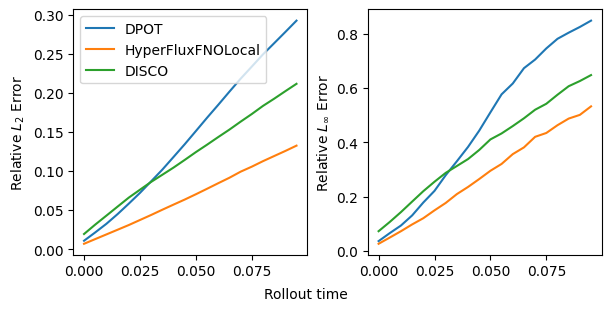

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3), constrained_layout=True)
for i, (model_type, u_pred) in enumerate(u_pred_dict.items()):
    rel_L2 = jnp.mean(
        jax.vmap(jax.vmap(relative_L2_error))(batch_test[:, 20:40], u_pred),
        axis=0,
    )
    axes[0].plot(jnp.arange(len(rel_L2)) * dt, rel_L2, label=model_type)

    rel_L_infty = jnp.mean(
        jax.vmap(jax.vmap(relative_L_infty_error))(batch_test[:, 20:40], u_pred),
        axis=0,
    )
    axes[1].plot(jnp.arange(len(rel_L_infty)) * dt, rel_L_infty, label=model_type)
axes[0].set_ylabel(r"Relative $L_2$ Error")
axes[1].set_ylabel(r"Relative $L_\infty$ Error")
fig.supxlabel("Rollout time", fontsize="medium")
axes[0].legend()


In [ ]:
dataset_test = (
    xr.open_dataset(
        datadir / "datasets/cubic_no_source/data/test/sine_1d_test_grf_seed=12.hdf5",
        engine="h5netcdf",
        chunks={},
    )
    .isel(t=slice(None, None, 10))
    .isel(t=slice(None, 80))
)

values = rearrange(dataset_test["values"].values, "pde ic ... -> (pde ic) ...")
segments = np.lib.stride_tricks.sliding_window_view(values, 21, axis=1)
segments = rearrange(segments, "batch t0 c x t -> (batch t0) t c x")
segments.shape

(600000, 21, 1, 100)

In [27]:
dt = float(dataset_test["t"][1] - dataset_test["t"][0])
dx = float(dataset_test["x"][1] - dataset_test["x"][0])
results = {}
for model_type, path in tqdm(model_paths.items()):
    model = load_model(checkpoint_dir / model_type / path)
    model = eqx.nn.inference_mode(model, True)

    @eqx.filter_jit
    def _compute_metrics(_u):
        _u_pred = model(_u[:-1], (dt, dx))[0]
        return {
            "L2": relative_L2_error(_u_pred, _u[-1]),
            "L_infty": relative_L_infty_error(_u_pred, _u[-1]),
        }

    results[model_type] = jax.tree.map(
        jnp.mean, jax.lax.map(_compute_metrics, segments, batch_size=2000)
    )

 33%|███▎      | 1/3 [00:09<00:18,  9.46s/it]/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/models/multiphysics/hyperfluxfno/encoders/utils.py:50: UserWarning: TRecViTEncoder supports variable in_timesteps. The given 
                    in_timesteps value will be ignored.
  warnings.warn(
/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/nn/structured_linear.py:40: UserWarning: out_features is not divisible by num_blocks. Output vector 
            will be truncated to the requested size.
  warnings.warn("""out_features is not divisible by num_blocks. Output vector
 67%|██████▋   | 2/3 [00:31<00:16, 16.90s/it]/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1269: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when res

In [28]:
results

{'DPOT': {'L2': Array(0.00605909, dtype=float32),
  'L_infty': Array(0.01189072, dtype=float32)},
 'HyperFluxFNOLocal': {'L2': Array(0.00261036, dtype=float32),
  'L_infty': Array(0.00643722, dtype=float32)},
 'DISCO': {'L2': Array(0.00732559, dtype=float32),
  'L_infty': Array(0.01543858, dtype=float32)}}

In [29]:
dataset_test

<xarray.Dataset> Size: 640MB
Dimensions:  (pde: 100, ic: 100, t: 80, dim: 1, x: 100, param: 2)
Coordinates:
  * t        (t) float64 640B 0.0 0.005 0.01 0.015 ... 0.38 0.385 0.39 0.395
  * dim      (dim) <U1 4B 'u'
  * x        (x) float64 800B 0.005 0.015 0.025 0.035 ... 0.975 0.985 0.995
  * param    (param) <U1 8B 'a' 'b'
Dimensions without coordinates: pde, ic
Data variables:
    values   (pde, ic, t, dim, x) float64 640MB dask.array<chunksize=(100, 100, 80, 1, 100), meta=np.ndarray>
    coeffs   (pde, param) float64 2kB dask.array<chunksize=(100, 2), meta=np.ndarray>

In [46]:
dataset_test = xr.open_dataset(
    datadir / "datasets/cubic_no_source/data/test/sine_1d_test_step_seed=12.hdf5",
    engine="h5netcdf",
    chunks={},
).isel(t=slice(None, None, 10))

values = rearrange(dataset_test["values"].values, "pde ic ... -> (pde ic) ...")
values.shape

(10000, 101, 1, 100)

In [47]:
dt = float(dataset_test["t"][1] - dataset_test["t"][0])
dx = float(dataset_test["x"][1] - dataset_test["x"][0])
results = {}
for model_type, path in tqdm(model_paths.items()):
    model = load_model(checkpoint_dir / model_type / path)
    model = eqx.nn.inference_mode(model, True)

    results[model_type] = jax.lax.map(
        eqx.filter_jit(lambda u: model.rollout(u, args=(dt, dx), num_steps=81)[0]),
        values[:, :20],
        batch_size=1000,
    )

 33%|███▎      | 1/3 [00:08<00:16,  8.02s/it]/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/models/multiphysics/hyperfluxfno/encoders/utils.py:50: UserWarning: TRecViTEncoder supports variable in_timesteps. The given 
                    in_timesteps value will be ignored.
  warnings.warn(
/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/nn/structured_linear.py:40: UserWarning: out_features is not divisible by num_blocks. Output vector 
            will be truncated to the requested size.
  warnings.warn("""out_features is not divisible by num_blocks. Output vector
 67%|██████▋   | 2/3 [00:30<00:16, 16.37s/it]/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1269: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when res

In [48]:
metrics_rollout = {}
for model_type, u_pred in results.items():
    l2 = jnp.mean(
        eqx.filter_vmap(eqx.filter_vmap(relative_L2_error))(u_pred, values[:, 20:]),
        axis=0,
    )
    l_inf = jnp.mean(
        eqx.filter_vmap(eqx.filter_vmap(relative_L_infty_error))(
            u_pred, values[:, 20:]
        ),
        axis=0,
    )
    metrics_rollout[model_type] = {"l2": l2, "l_inf": l_inf}

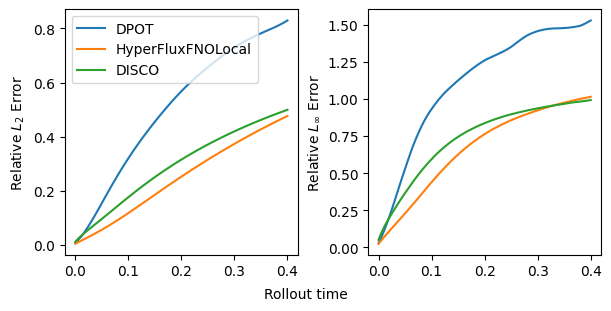

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3), constrained_layout=True)
for model_type, met in metrics_rollout.items():
    axes[0].plot(jnp.arange(len(met["l2"])) * dt, met["l2"], label=model_type)

    axes[1].plot(jnp.arange(len(met["l2"])) * dt, met["l_inf"], label=model_type)
axes[0].set_ylabel(r"Relative $L_2$ Error")
axes[1].set_ylabel(r"Relative $L_\infty$ Error")
fig.supxlabel("Rollout time", fontsize="medium")
axes[0].legend()


In [43]:
dt

0.005

## Evaluate l2, l\infty losses

In [29]:
import numpy as np
from einops import rearrange


dataset_test = xr.open_dataset(
    datadir / "cubic_no_source_large_test_seed=10.hdf5", engine="h5netcdf", chunks={}
).isel(t=slice(None, None, 10))


sample = dataset_test["values"].isel({"pde": 0}).compute()
inputs = np.lib.stride_tricks.sliding_window_view(sample, (21,), axis=1)
inputs.shape

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/home/jhko725/projects/CONTEXT_FLUX_NO/data/cubic_no_source_large_test_seed=10.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [28]:
# model = load_model(
#     checkpoint_dir / "DPOT" / "OneStepLoss" / CHECKPOINT_DICT["DPOT"]["OneStepLoss"]
# )
model = load_model(
    checkpoint_dir
    / "HyperFluxFNO"
    / "OneStepLoss"
    / CHECKPOINT_DICT["HyperFluxFNO"]["OneStepLoss"]
)
model = eqx.nn.inference_mode(model, True)

In [29]:
dt = float(dataset_test["t"][1] - dataset_test["t"][0])
dx = float(dataset_test["x"][1] - dataset_test["x"][0])


@eqx.filter_jit
def compute_metrics(model, data):
    u_pred = eqx.filter_vmap(model, in_axes=(0, None))(data[:, :-1], (dt, dx))[0]
    u_target = data[:, -1]
    l2 = jnp.mean(jnp.sqrt(jnp.mean((u_pred - u_target) ** 2, axis=-1)))
    l_infty = jnp.mean(jnp.max(jnp.abs(u_pred - u_target), axis=-1))
    return {"l2": l2, "l_infty": l_infty}

In [30]:
metrics = []
for i in tqdm(range(dataset_test["values"].shape[0])):
    sample = dataset_test["values"].isel({"pde": i}).compute()
    inputs = np.lib.stride_tricks.sliding_window_view(sample, (21,), axis=1)
    inputs_batched = rearrange(inputs, "ic t_start c x t -> (ic t_start) t c x")
    metrics.append(compute_metrics(model, inputs_batched))

  0%|          | 0/100 [00:00<?, ?it/s]E0401 10:26:15.790682 2252771 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0401 10:26:16.082994 2252771 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0401 10:26:16.372723 2252771 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0401 10:26:16.662176 2252771 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0401 10:26:16.951792 2252771 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0401 

In [31]:
metrics_mean = jax.tree.map(
    lambda x: {"mean": np.mean(x), "std": np.std(x)},
    jax.tree.transpose(jax.tree.structure(["*"] * len(metrics)), None, metrics),
    is_leaf=lambda x: isinstance(x, list),
)

In [32]:
metrics_mean

{'l2': {'mean': np.float32(0.0013744155), 'std': np.float32(0.00013876914)},
 'l_infty': {'mean': np.float32(0.008146128), 'std': np.float32(0.000692608)}}